# Indian Railways: Comprehensive Operations & Network Connectivity Analysis

## Level 1: Data Exploration and Basic Operations

### Task 1.1: Load and Inspect Data

In [3]:
# Using pandas for cleaning , exploration and analyzing data 
import pandas as pd

In [4]:
# Importing my dataset and importing it into a dataframe
df = pd.read_csv(r"C:\Users\Kshitiz Singh\Downloads\Railway_info.csv")

In [5]:
# Loading my dataset in dataframe
df

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
...,...,...,...,...,...
11108,99904,PUNE-TGN EMU,PUNE JN.,TALEGAON,Tuesday
11109,99905,EMU,TALEGAON,SHIVAJINAGAR,Monday
11110,99906,EMU,PUNE JN.,TALEGAON,Wednesday
11111,99907,EMU,TALEGAON,PUNE JN.,Thursday


In [6]:
# Loading first 10 rows of dataset 
df.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
5,421,LKO-SVDK FTR,LUCKNOW JN.,SHRI MATA VAISHNO DEVI KATRA,Tuesday
6,422,SVDK-LKO FTR,SHRI MATA VAISHNO DEVI KATRA,LUCKNOW JN.,Monday
7,477,FTR TRAIN NO,SIRSA,SIRSA,Sunday
8,502,RJPB-UMB FTR,RAJENDRANAGAR TERMINAL,AMBALA CANTT JN,Monday
9,504,PNBE-BTI FTR,PATNA JN.,BATHINDA JN,Wednesday


### Task 1.2: Basic Statistics

In [8]:
# No. of total train
total_trains = len(df)
print(f"Total number of trains : {total_trains}")

Total number of trains : 11113


In [9]:
# Unique source & Unique destination
unique_sources = df["Source_Station_Name"].nunique()
unique_destinations = df["Destination_Station_Name"].nunique()

In [10]:
print(f"Number of Unique Source Stations : {unique_sources}")

Number of Unique Source Stations : 921


In [11]:
print(f"Number of Destination Source Station : {unique_destinations}")

Number of Destination Source Station : 924


In [12]:
# Most common source & destination stations
most_common_source = df["Source_Station_Name"].value_counts().idxmax()
most_common_destination = df["Destination_Station_Name"].value_counts().idxmax()

In [13]:
print(f"The most common Source Station is : {most_common_source}")

The most common Source Station is : CST-MUMBAI


In [14]:
print(f"The most common Destinations Station is : {most_common_destination}")

The most common Destinations Station is : CST-MUMBAI


In [15]:
# Number of common source station
most_common_source = df["Source_Station_Name"].value_counts()
print(f"The most common Source Station is : {most_common_source}")

The most common Source Station is : Source_Station_Name
CST-MUMBAI           513
SEALDAH              372
CHENNAI BEACH        339
HOWRAH JN.           338
KALYAN JN            285
                    ... 
URKURA                 1
ANDHERI                1
THAKURNAGAR            1
DUMDUM CANTONMENT      1
GADWAL                 1
Name: count, Length: 921, dtype: int64


In [16]:
# Number of common destination station
most_common_destination = df["Destination_Station_Name"].value_counts()
print(f"The most common Destinations Station is : {most_common_destination}")

The most common Destinations Station is : Destination_Station_Name
CST-MUMBAI       514
SEALDAH          373
CHENNAI BEACH    342
HOWRAH JN.       337
KALYAN JN        284
                ... 
SONARDIH           1
PIDUGURALLA        1
KUSUNDA            1
GADWAL             1
KHADKI             1
Name: count, Length: 924, dtype: int64


In [17]:
# Checking how many trains leave from top 5 stations
print("\n Top 3 Source Stations with their counts:")
print(df["Source_Station_Name"].value_counts().head(5))


 Top 3 Source Stations with their counts:
Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
Name: count, dtype: int64


### Task 1.3: Data Cleaning

In [40]:
# Checking for missing values in each column 
print(df.isnull().sum())

Train_No                       0
Train_Name                     0
Source_Station_Name            0
Destination_Station_Name       0
days                        1153
Category                       0
Train_Type                     0
corridor                       0
route                          0
Train_Types                    0
Train_Category                 0
dtype: int64


In [18]:
# Standardizing the format of station names & also removing the invisible spaces at start and end
df["Source_Station_Name"] = df["Source_Station_Name"].str.strip().str.upper()
df["Destination_Station_Name"] = df["Destination_Station_Name"].str.strip().str.upper()

In [19]:
# Print for first 5 rows to verify the code
print(df[["Source_Station_Name","Destination_Station_Name"]].head())

  Source_Station_Name            Destination_Station_Name
0     SAWANTWADI ROAD                         MADGOAN JN.
1         MADGOAN JN.                     SAWANTWADI ROAD
2         MADGOAN JN.  CHHATRAPATI SHAHU MAHARAJ TERMINUS
3   DELHI-SAFDAR JANG                   DELHI-SAFDAR JANG
4          AURANGABAD                        VARANASI JN.


## Level 2: Data Transformation and Aggregation

### Task 2.1: Data Filtering

In [20]:
# Get a list of all unique source stations and destination stations
sources = set(df['Source_Station_Name'].unique())
destinations = set(df['Destination_Station_Name'].unique())

# Find stations that are Destinations, but NEVER Sources
dest_only = destinations - sources
print(f"Stations that are ONLY destinations ({len(dest_only)} stations):")
print(dest_only)

# Find stations that are Sources, but NEVER Destinations
source_only = sources - destinations
print(f"\nStations that are ONLY sources ({len(source_only)} stations):")
print(source_only)

Stations that are ONLY destinations (12 stations):
{'BANDA JN', 'SRIKAKULAM ROAD', 'NANDURBAR', 'GHUTIARI SHARIF', 'VANGAICHUNGPAO', 'JALESWAR', 'PANJIPARA', 'SHMATA VD KATRA', 'KHADKI', 'GOMTINAGAR F', 'RAHIMABAD', 'PAYYANUR'}

Stations that are ONLY sources (9 stations):
{'BAGNAN', 'KANKURGACHHI ROAD JN.', 'DOMBIVLI CTL', 'CHAMPAHATI', 'JIRIBAM', 'TIRUNINRAVUR', 'URKURA', 'PATTABIRAM EAST CABIN', 'VIDYAVIHAR'}


In [21]:
# Filter the data to show trains that operate on specific days (e.g., only on Saturdays).
saturday_trains = df[df["days"].str.contains("Saturday", case = False , na = False)]
print("\n ----- Trains Operating on Saturdays -------")
print(saturday_trains)


 ----- Trains Operating on Saturdays -------
       Train_No    Train_Name Source_Station_Name Destination_Station_Name  \
0           107  SWV-MAO-VLNK     SAWANTWADI ROAD              MADGOAN JN.   
4           401  BSB BHARATDA          AURANGABAD             VARANASI JN.   
21         1196  NGP-KRMI SPL      NAGPUR JN.(CR)                  KARMALI   
28         1706   JBP-BDTS SF            JABALPUR          BANDRA TERMINUS   
45         2834  SRC-RJT SF A     SANTRAGACHI JN.                   RAJKOT   
...         ...           ...                 ...                      ...   
11084     99816  PUNE-LNL EMU            PUNE JN.                  LONAVLA   
11086     99818      PUNE-LNL            PUNE JN.                  LONAVLA   
11094     99826  PUNE-LNL EMU            PUNE JN.                  LONAVLA   
11100     99832  PUNE-LNL EMU        SHIVAJINAGAR                  LONAVLA   
11104     99836  PUNE-TGN EMU            PUNE JN.                  LONAVLA   

           days  

In [22]:
# Extract and create a new dataframe for trains that start from a specific station.
lucknow_trains_df = df[df["Source_Station_Name"] == "LUCKNOW JN."].copy()
print(lucknow_trains_df.head())

     Train_No    Train_Name Source_Station_Name      Destination_Station_Name  \
5         421  LKO-SVDK FTR         LUCKNOW JN.  SHRI MATA VAISHNO DEVI KATRA   
91       5066   LJN-CPR-EXP         LUCKNOW JN.                   CHHAPRA JN.   
380     11110  LKO -JHS INT         LUCKNOW JN.                     JHANSI JN   
411     11408  LJN-PUNE EXP         LUCKNOW JN.                      PUNE JN.   
434     12003  LKO-NDLS SHA         LUCKNOW JN.                     NEW DELHI   

         days  
5     Tuesday  
91   Saturday  
380    Friday  
411  Saturday  
434    Sunday  


### Task 2.2: Grouping and Aggregation

In [23]:
# Group the data by source station and count the number of trains originating from each station.
station_counts = df.groupby("Source_Station_Name").size().reset_index(name = "Train_Count")
# Sorting the results from highest to lowest
station_counts = station_counts.sort_values(by = "Train_Count", ascending = False)
print("\n ----- No. of Trains Originating from each station -----")
print(station_counts.head(10)) # Showing top 10 busiest station


 ----- No. of Trains Originating from each station -----
    Source_Station_Name  Train_Count
224          CST-MUMBAI          513
773             SEALDAH          372
201       CHENNAI BEACH          339
373          HOWRAH JN.          338
426           KALYAN JN          285
843               THANE          186
660              PANVEL          141
832            TAMBARAM          140
585         MOOR MARKET          135
894          VELACHEERY          115


In [24]:
# Find the average number of trains per day for each source station.

# Step 1: Count the number of trains for each station on each day
daily_counts = df.groupby(["Source_Station_Name", "days"]).size().reset_index(name="Daily_Count")

# Step 2: Calculate the average of those daily counts for each station 
# (Notice this is all on ONE line now)
avg_trains = daily_counts.groupby("Source_Station_Name")["Daily_Count"].mean().reset_index(name="Avg_Trains_Per_Day")

# Sort from highest average to lowest
avg_trains = avg_trains.sort_values(by="Avg_Trains_Per_Day", ascending=False)

print("\n----- Average Number of Trains Per Day by Station ----- ")
print(avg_trains.head(10))


----- Average Number of Trains Per Day by Station ----- 
    Source_Station_Name  Avg_Trains_Per_Day
224          CST-MUMBAI           51.300000
773             SEALDAH           41.333333
426           KALYAN JN           40.714286
373          HOWRAH JN.           30.727273
843               THANE           26.571429
201       CHENNAI BEACH           24.214286
832            TAMBARAM           20.000000
660              PANVEL           17.625000
894          VELACHEERY           16.428571
634           NEW DELHI           15.285714


### Task 2.3: Data Enrichment

In [25]:
# Add a new column that categorizes trains based on their operating days (e.g., 'Weekday', 'Weekend').
import numpy as np 
df["Category"] = np.where(
    df["days"].str.contains("Saturday|Sunday " , case = False , na = False),
    "Weekend",
    "Weekdays")

# View the result (Printing 1st 20 row to verify)
print(df[["Train_No" , "Train_Name", "days","Category"]].head(20))


    Train_No        Train_Name       days  Category
0        107      SWV-MAO-VLNK   Saturday   Weekend
1        108      VLNK-MAO-SWV     Friday  Weekdays
2        128      MAO-KOP SPEC     Friday  Weekdays
3        290      PALACE ON WH  Wednesday  Weekdays
4        401      BSB BHARATDA   Saturday   Weekend
5        421      LKO-SVDK FTR    Tuesday  Weekdays
6        422      SVDK-LKO FTR     Monday  Weekdays
7        477      FTR TRAIN NO     Sunday  Weekdays
8        502      RJPB-UMB FTR     Monday  Weekdays
9        504      PNBE-BTI FTR  Wednesday  Weekdays
10       506      PNBE-PTA FTR     Friday  Weekdays
11       557       RSD-PJP BSF  Wednesday  Weekdays
12     22439  SVDK VANDEBHARAT     Friday  Weekdays
13       604      PNBE-ASR FTR   Thursday  Weekdays
14      1011       CSMT-NGP SF   Thursday  Weekdays
15      1037       LTT-SWV SPL    Tuesday  Weekdays
16      1038       SWV-LTT SPL    Tuesday  Weekdays
17      1045      LTT-KRMI SPL   Thursday  Weekdays
18      1119

## Level 3: Advanced Data Analysis

### Task 3.1: Pattern Analysis

--- Train Distribution by Day ---
days
Monday       1342
Tuesday      1454
Wednesday    1448
Thursday     1372
Friday       1471
Saturday     1441
Sunday       1432
Name: count, dtype: int64


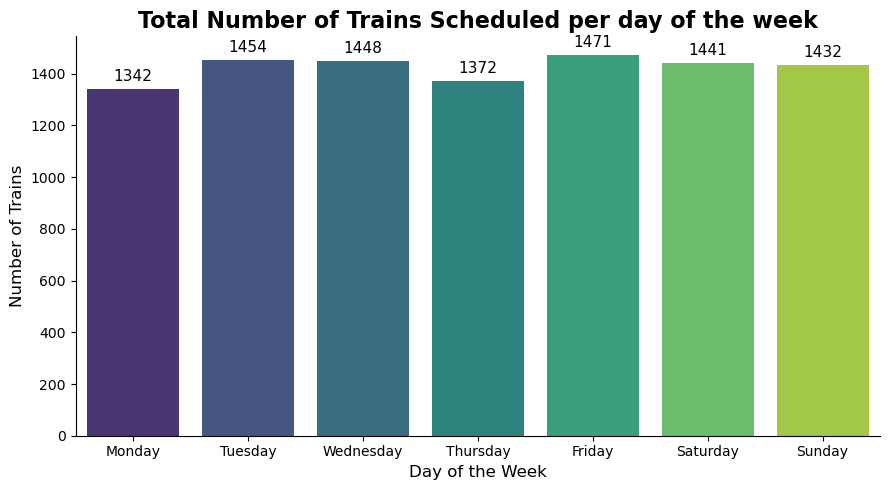

In [26]:
# Analyze the distribution of train journeys throughout the week. Visualize the results using bar plots or histograms.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize text (strip empty spaces and capitalize the first letter)
df['days'] = df['days'].str.strip().str.title()

#  Order the days of the week logically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert the 'days' column to a Categorical type so it sorts in the correct order
df['days'] = pd.Categorical(df['days'], categories=days_order, ordered=True)

#  Count the number of trains per day
day_counts = df['days'].value_counts().sort_index()

# Print the numerical data to the console
print("--- Train Distribution by Day ---")
print(day_counts)

#  Visualize the data using a Bar Plot
plt.figure(figsize=(9,5)) # Set the size of the chart

# Create a colorful bar chart using Seaborn
ax = sns.countplot(data=df, x ="days", hue = "days" , legend = False , palette='viridis')

# Add titles and labels
plt.title('Total Number of Trains Scheduled per day of the week', fontsize =16, fontweight ='bold')
plt.xlabel('Day of the Week', fontsize =12)
plt.ylabel('Number of Trains', fontsize =12)

# Add data labels (numbers) on top of each bar for easy reading
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize = 11)

# Clean up the layout and display the plot
sns.despine() # Removes the top and right borders
plt.tight_layout()
plt.show()

------1. Top 5 Busiest Operational Hubs (Source) -------
Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
Name: count, dtype: int64


--------2. Top 5 Busiest Corridors (Total Two Way Traffic)-------
corridor
CHENNAI BEACH-TAMBARAM      274
CST-MUMBAI-PANVEL           187
CST-MUMBAI-RAVLI JN         180
CHENNAI BEACH-VELACHEERY    176
CST-MUMBAI-THANE            149
Name: count, dtype: int64


--- 3. Operational Load by Day of Week ---
days
Monday       1342
Tuesday      1454
Wednesday    1448
Thursday     1372
Friday       1471
Saturday     1441
Sunday       1432
Name: count, dtype: int64




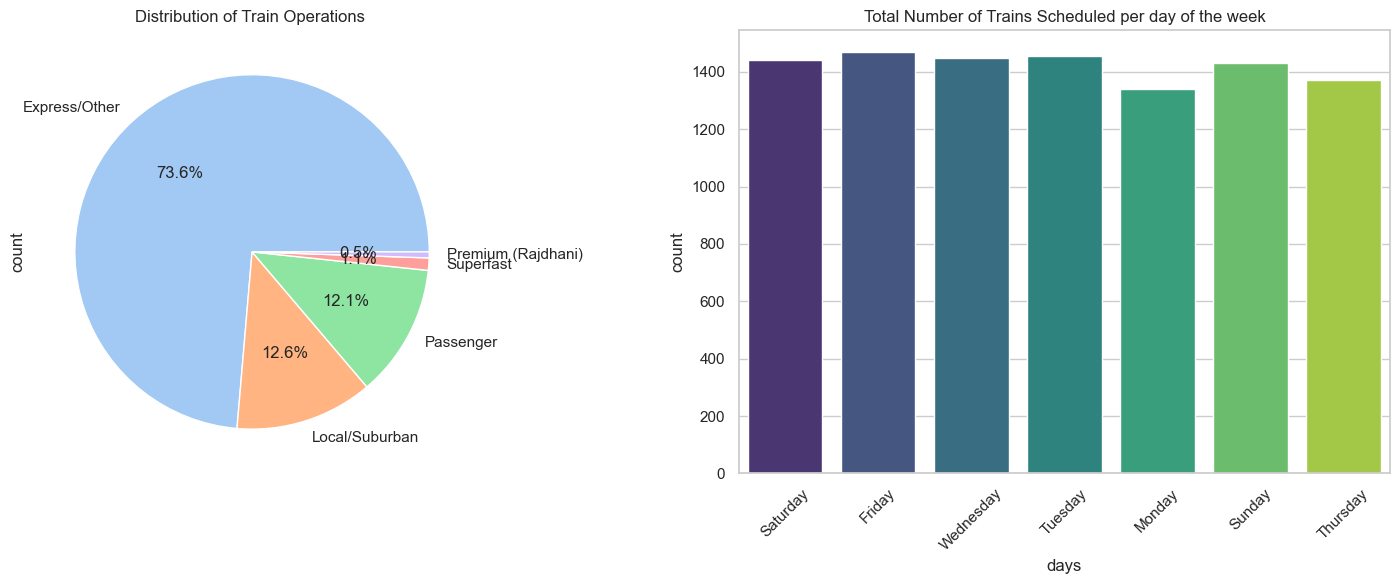

In [41]:
# Identify patterns or trends in the train operations based on source and destination stations.
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# DATA CLEANING & TRANSFORMATION
def clean_railway_data(df):
    # Remove whitespace from headers and strings
    df.columns = df.columns.str.strip()
    
    # Normalize "days" - remove the trailing 'd' found in local train records
    df['days'] = df['days'].str.replace('d$', '', regex=True).str.strip()

    # Identify Train Type based on Name (Pattern recognition) 
    def categorize_train(name):
        name = str(name).upper()
        if 'EMU' in name or 'LOCAL' in name : return 'Local/Suburban'
        if 'RAJ' in name : return 'Premium (Rajdhani)'
        if 'PASS' in name or 'PGR' in name : return 'Passenger'
        if 'SF' in name or 'SUPER' in name : return 'Superfast'
        return 'Express/Other'

    df["Train_Type"] = df["Train_Name"].apply(categorize_train)

    # Create a Corridor ID (A-B and B-A are the same corridor)
    df["corridor"] = df.apply(lambda x: "-".join(sorted([x["Source_Station_Name"],x["Destination_Station_Name"]])), axis = 1)

    # Create Route ID (Direction specific)
    df["route"] = df["Source_Station_Name"] + "->" + df["Destination_Station_Name"]
    return df

df = clean_railway_data(df)

# ANALYSIS & PATTERN IDENTIFICATION
print("------1. Top 5 Busiest Operational Hubs (Source) -------")
print(df["Source_Station_Name"].value_counts().head(5))
print("\n")

print("--------2. Top 5 Busiest Corridors (Total Two Way Traffic)-------")
print(df["corridor"].value_counts().head(5))
print("\n")

print("--- 3. Operational Load by Day of Week ---")
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print(df['days'].value_counts().reindex(day_order))
print("\n")

# VISULIZATION OF TRENDS
def plot_trends(df):
    plt.figure(figsize = (15,6))

    # Pattern A : Volume of Train Types 
    plt.subplot(1,2,1)
    df["Train_Type"].value_counts().plot(kind = "pie" , autopct = "%1.1f%%", colors = sns.color_palette("pastel"))
    plt.title("Distribution of Train Operations ")

    # Pattern B : Daily Traffic Trend
    plt.subplot(1,2,2)
    sns.countplot(data = df , x = "days" , hue = "days" , legend = False , palette = "viridis")
    plt.title("Total Number of Trains Scheduled per day of the week")
    plt.xticks(rotation = 45)

    plt.tight_layout()
    plt.show()

plot_trends(df)

### Task 3.2: Correlation and Insights


Total Scheduled per day: 
days
Monday       1342
Tuesday      1454
Wednesday    1448
Thursday     1372
Friday       1471
Saturday     1441
Sunday       1432
Name: count, dtype: int64


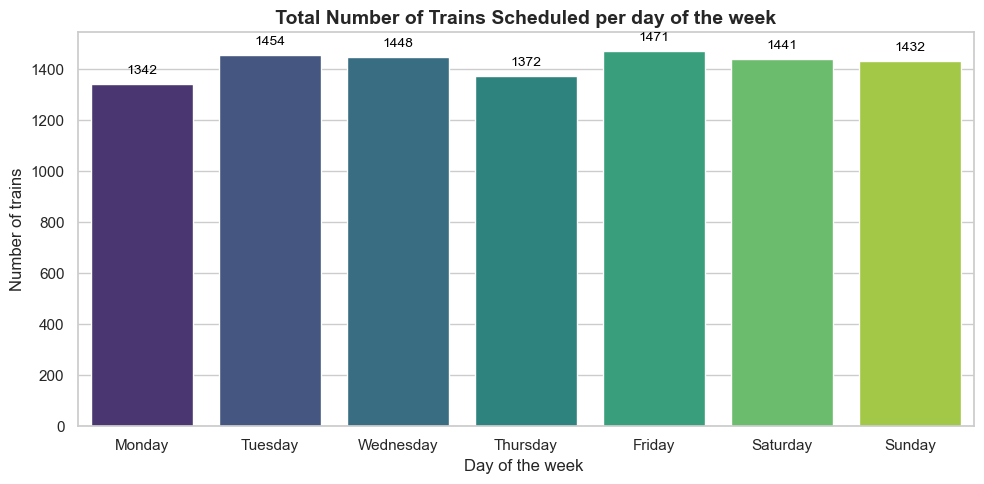

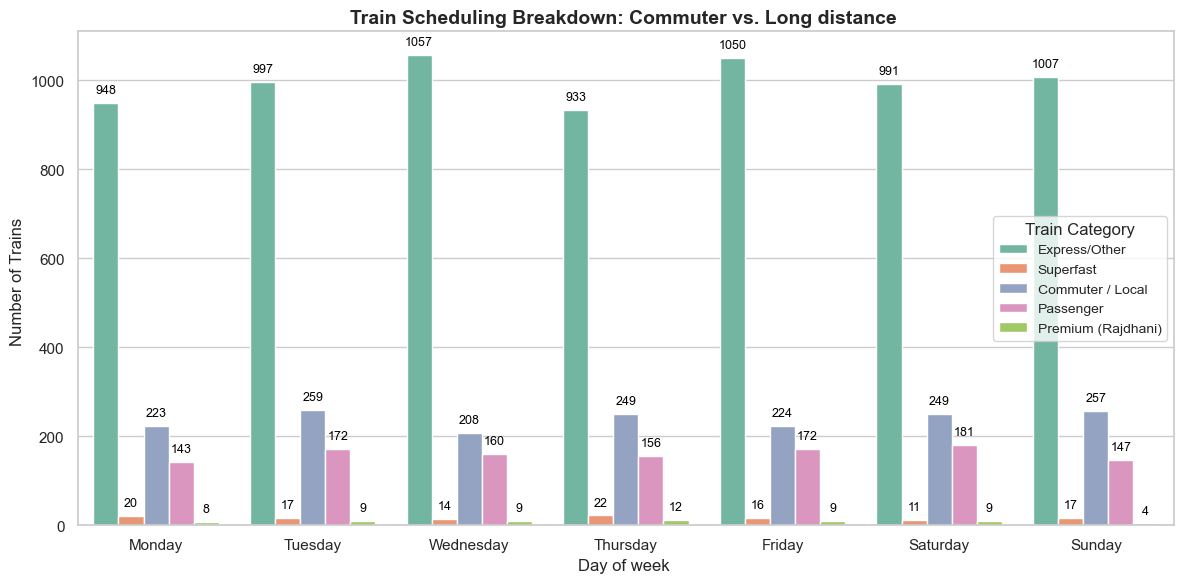

In [43]:
# Explore if there is any correlation between the number of trains and specific days of the week.Provide insights and recommendations based on the analysis.

# Converting the "days" colun to categorical type to ensure logical sorting (Mon-Sun)

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["days"] = pd.Categorical(df["days"], categories = day_order, ordered = True)

# Categorical Train Types (Commuter vs. Long Distance)

# Based on the analysis , suburban/local trains heavily dictate the schedule 
# We will identify them using keywords in the "Train_Name" column.
commuter_keywords = ["EMU" , "MEMU" , "DEMU" , "LOC", "LOCAL","SUB"]
pattern = '|' . join(commuter_keywords)

# Create a new column categorizing the trains 
df["Train_Types"] = "Long Distance / Others"
df.loc[df["Train_Name"].str.contains(pattern , case = False , na = False),"Train_Type"] = "Commuter / Local " 

# Frequency Analysis 

# Calculate total trains per day
days_counts = df["days"].value_counts().sort_index()
print("\nTotal Scheduled per day: ")
print(days_counts)

# Data Visualization 
sns.set_theme(style = "whitegrid")

# Plot 1 : Total trains per day 
plt.figure(figsize = (10,5))
ax1 = sns.countplot(data = df , x = "days" , hue = "days" , legend = False , palette = "viridis")
plt.title(" Total Number of Trains Scheduled per day of the week ", fontsize = 14 , fontweight = "bold")
plt.xlabel("Day of the week ", fontsize = 12)
plt.ylabel("Number of trains", fontsize = 12 )

# Add value labels on top of the bars 
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center" , va = "bottom", fontsize = 10, color = "black", xytext = (0,5) , textcoords = "offset points ")
    plt.tight_layout()
plt.show()

# Plot 2 : Commuter vs Long distance trains per day 
plt.figure(figsize = (12,6))
ax2 = sns.countplot(data = df , x = "days" , hue = "Train_Type", order = day_order , palette = "Set2")
plt.title("Train Scheduling Breakdown: Commuter vs. Long distance ", fontsize = 14 , fontweight = "bold")
plt.xlabel("Day of week ", fontsize = 12)
plt.ylabel("Number of Trains ", fontsize = 12 )
plt.legend(title = "Train Category" , fontsize = 10)

# Add value labels on top of the grouped bars 
for p in ax2.patches:
    if p.get_height() > 0: # Only add label if height is greater than 0 
        ax2.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/ 2., p.get_height()), ha = "center" , va = "bottom", fontsize = 9 , color = "black" , xytext = (0,5), textcoords = "offset points " )
        plt.tight_layout()
plt.show()

## Level 4: Data Visualization and Reporting

### Task 4.1: Visualization

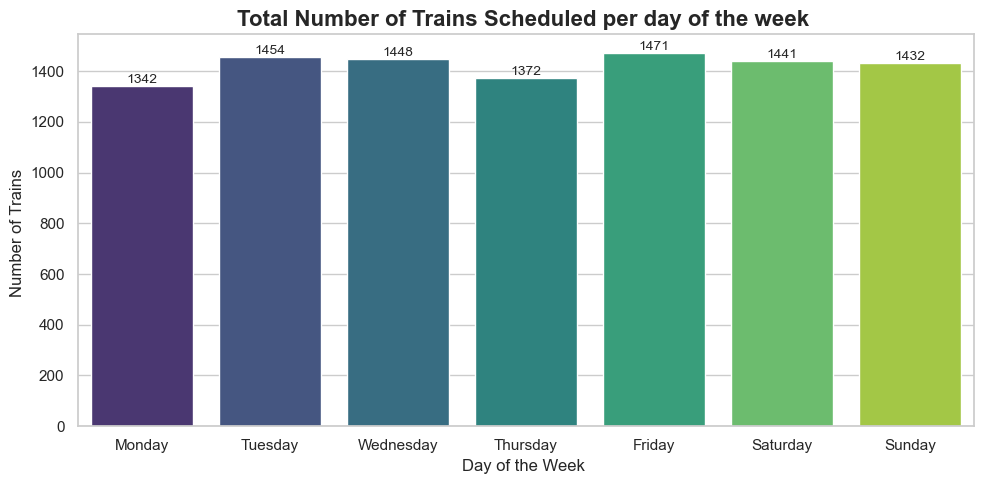

In [29]:
# Create visualizations (bar charts, line charts, heatmaps) to represent various aspects of the data (e.g., number of trains per station, day-wise distribution).
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Data Visulization
sns.set_theme(style = "whitegrid")

# Chart 1 : Day_wise Distribution (Bar Chart) 
plt.figure(figsize = (10,5))
ax = sns.countplot(data = df , x = "days" , hue = "days" , legend = False , palette = "viridis")
plt.title("Total Number of Trains Scheduled per day of the week ", fontsize = 16 , fontweight = "bold")
plt.xlabel("Day of the Week " , fontsize = 12 )
plt.ylabel("Number of Trains ", fontsize = 12 ) 

# Add exact numbers on top of bars 
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",(p.get_x() + p.get_width() / 2., p.get_height()), ha = "center" , va = "bottom" , fontsize = 10 )
    plt.tight_layout()
plt.show()

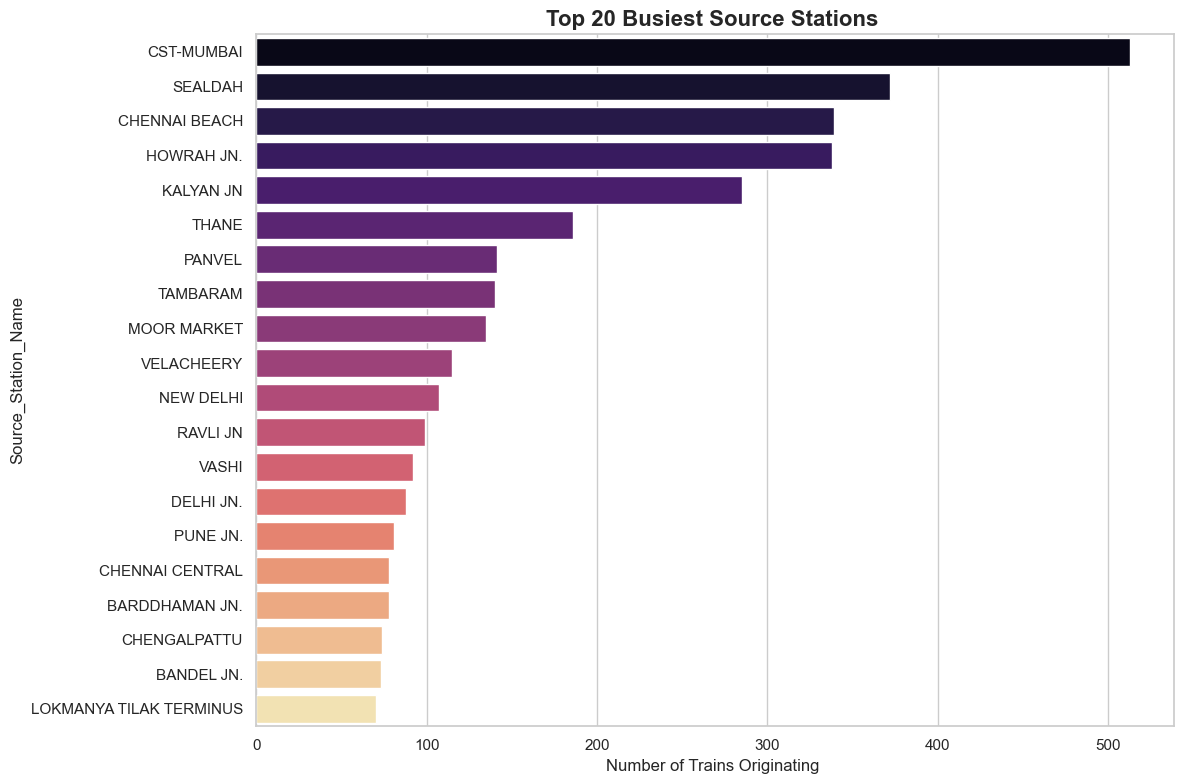

In [30]:
# Chart 2 : Top 20 Source Stations (Bar Chart)
plt.figure(figsize = (12,8))
top_sources = df["Source_Station_Name"].value_counts().head(20)
sns.barplot( x = top_sources.values , y = top_sources.index , hue = top_sources.index, legend = False, palette = "magma")
plt.title("Top 20 Busiest Source Stations " , fontsize = 16 , fontweight = "bold")
plt.xlabel("Number of Trains Originating " , fontsize = 12)
plt.tight_layout()
plt.show()

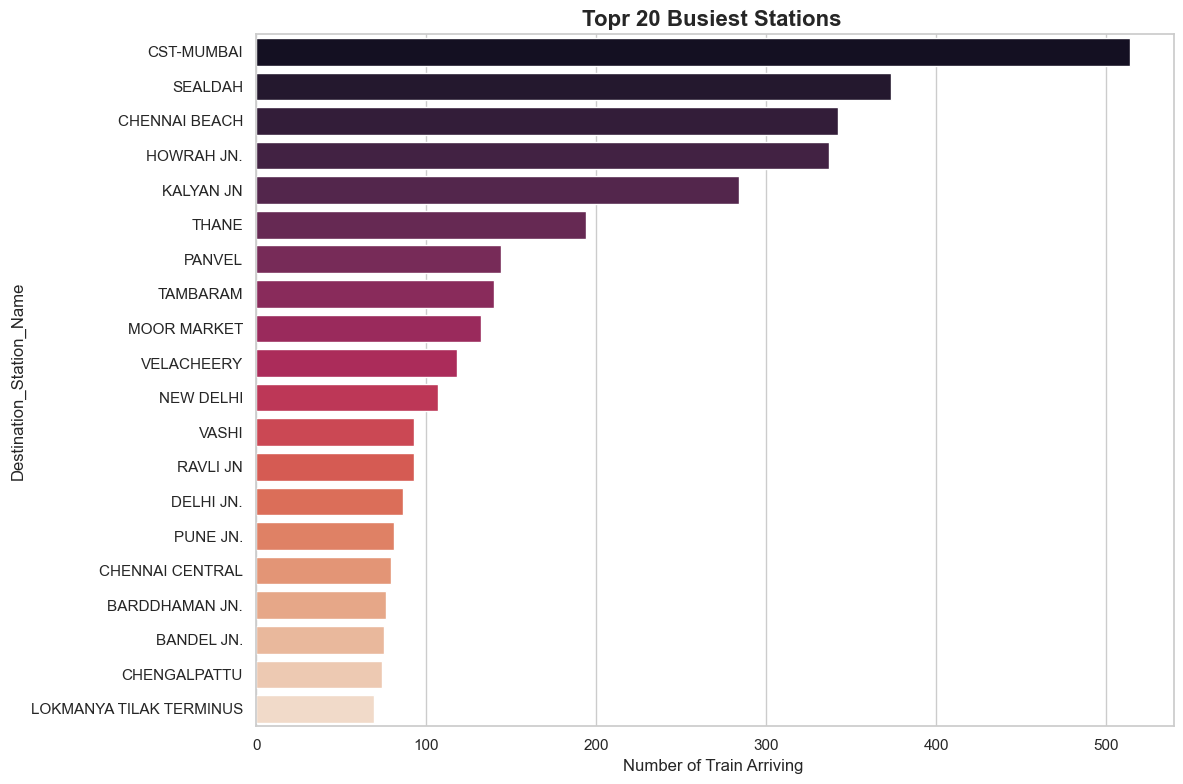

In [31]:
# Chart 3 : Top 20 Destination Stations (Bar Chart) 
plt.figure(figsize = (12,8))
top_dests = df["Destination_Station_Name"].value_counts().head(20)
sns.barplot(x = top_dests.values , y = top_dests.index , hue = top_dests.index , legend = False , palette = "rocket")
plt.title("Topr 20 Busiest Stations " , fontsize = 16, fontweight = "bold")
plt.xlabel("Number of Train Arriving " , fontsize = 12)
plt.tight_layout()
plt.show()

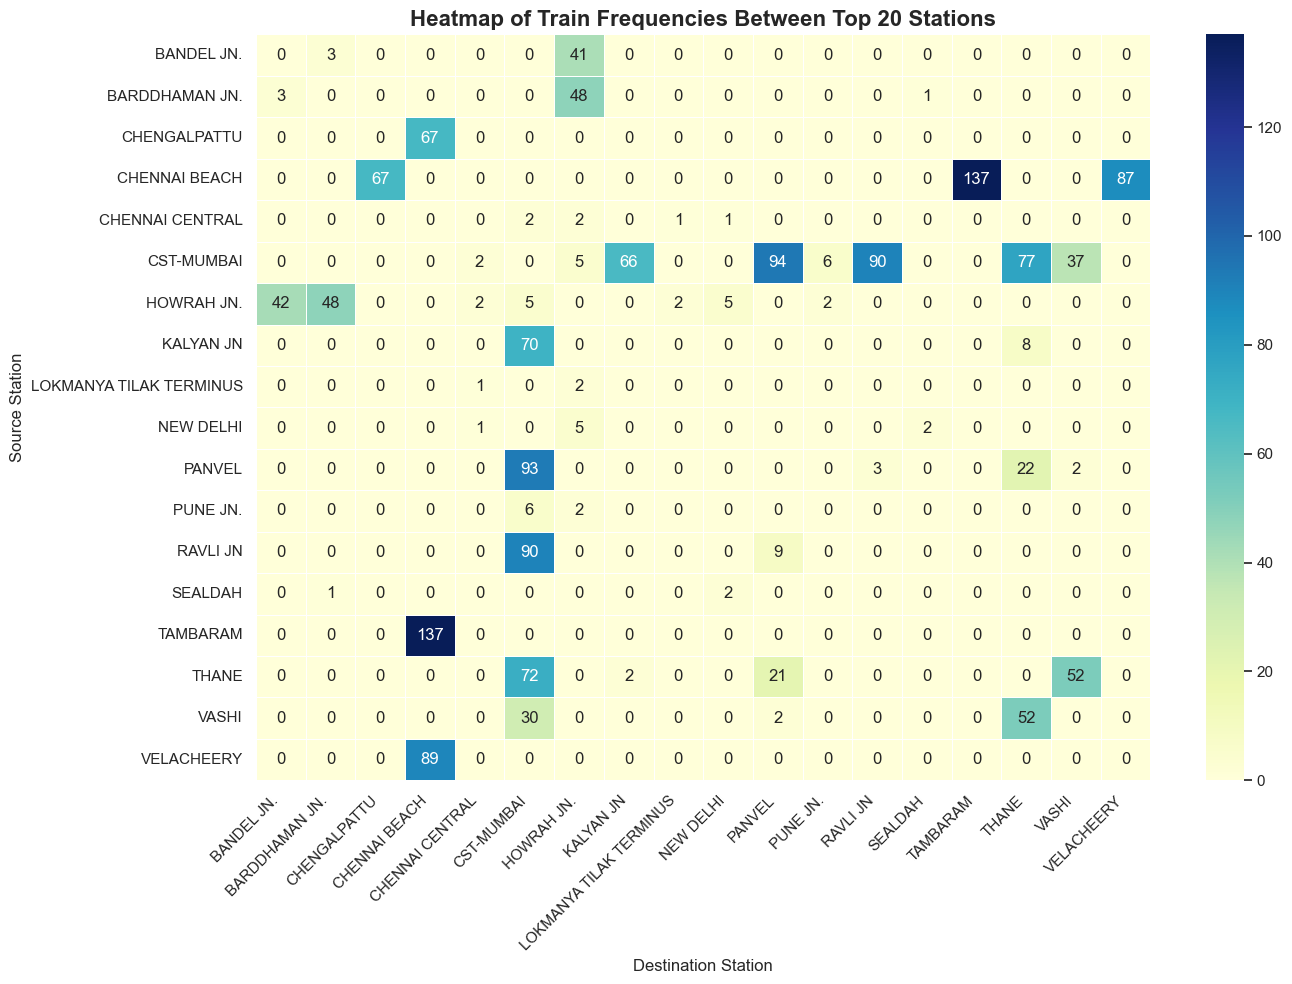

In [32]:
# Chart 4 : Source vs Destination (Heatmap)

# Get the top 20 most frequent stations overall to create a clean matrix 
top_stations = pd.concat([df["Source_Station_Name"],df["Destination_Station_Name"]]).value_counts().head(20).index

# Filter dataset to only include routes between these top 20 stations 
heatmap_data = df[df["Source_Station_Name"].isin(top_stations)&df["Destination_Station_Name"].isin(top_stations)]

# Create a cross_tabulation matrix 
route_matrix = pd.crosstab(heatmap_data["Source_Station_Name"],heatmap_data["Destination_Station_Name"])

plt.figure(figsize = (14,10))
sns.heatmap(route_matrix , annot = True , fmt = "d" , cmap = "YlGnBu", linewidth = 0.5)
plt.title("Heatmap of Train Frequencies Between Top 20 Stations", fontsize = 16 , fontweight = "bold")
plt.xlabel("Destination Station" , fontsize = 12)
plt.ylabel("Source Station", fontsize = 12)
plt.xticks(rotation = 45 , ha = "right")
plt.tight_layout()
plt.show()
    

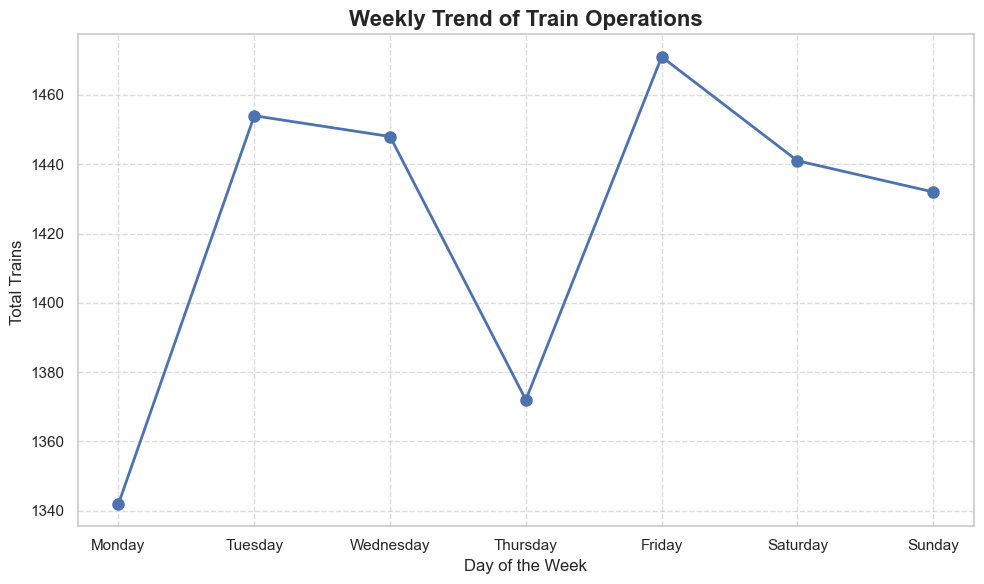

Visulizations Generated Successfully


In [33]:
# Chart 5 : Trend across the week (line chart)
plt.figure(figsize = (10,6))
day_counts = df["days"].value_counts().reindex(days_order)
plt.plot(day_counts.index,day_counts.values, marker = "o" , linestyle = "-", color = "b" , linewidth = 2 , markersize = 8)
plt.title("Weekly Trend of Train Operations" , fontsize = 16 , fontweight = "bold")
plt.xlabel("Day of the Week", fontsize = 12)
plt.ylabel("Total Trains " , fontsize = 12)
plt.grid(True , linestyle = "--" , alpha = 0.7)
plt.tight_layout()
plt.show()

print("Visulizations Generated Successfully")

### Task 4.2: Reporting

Categorizing train Types...

Generating Visualizations...


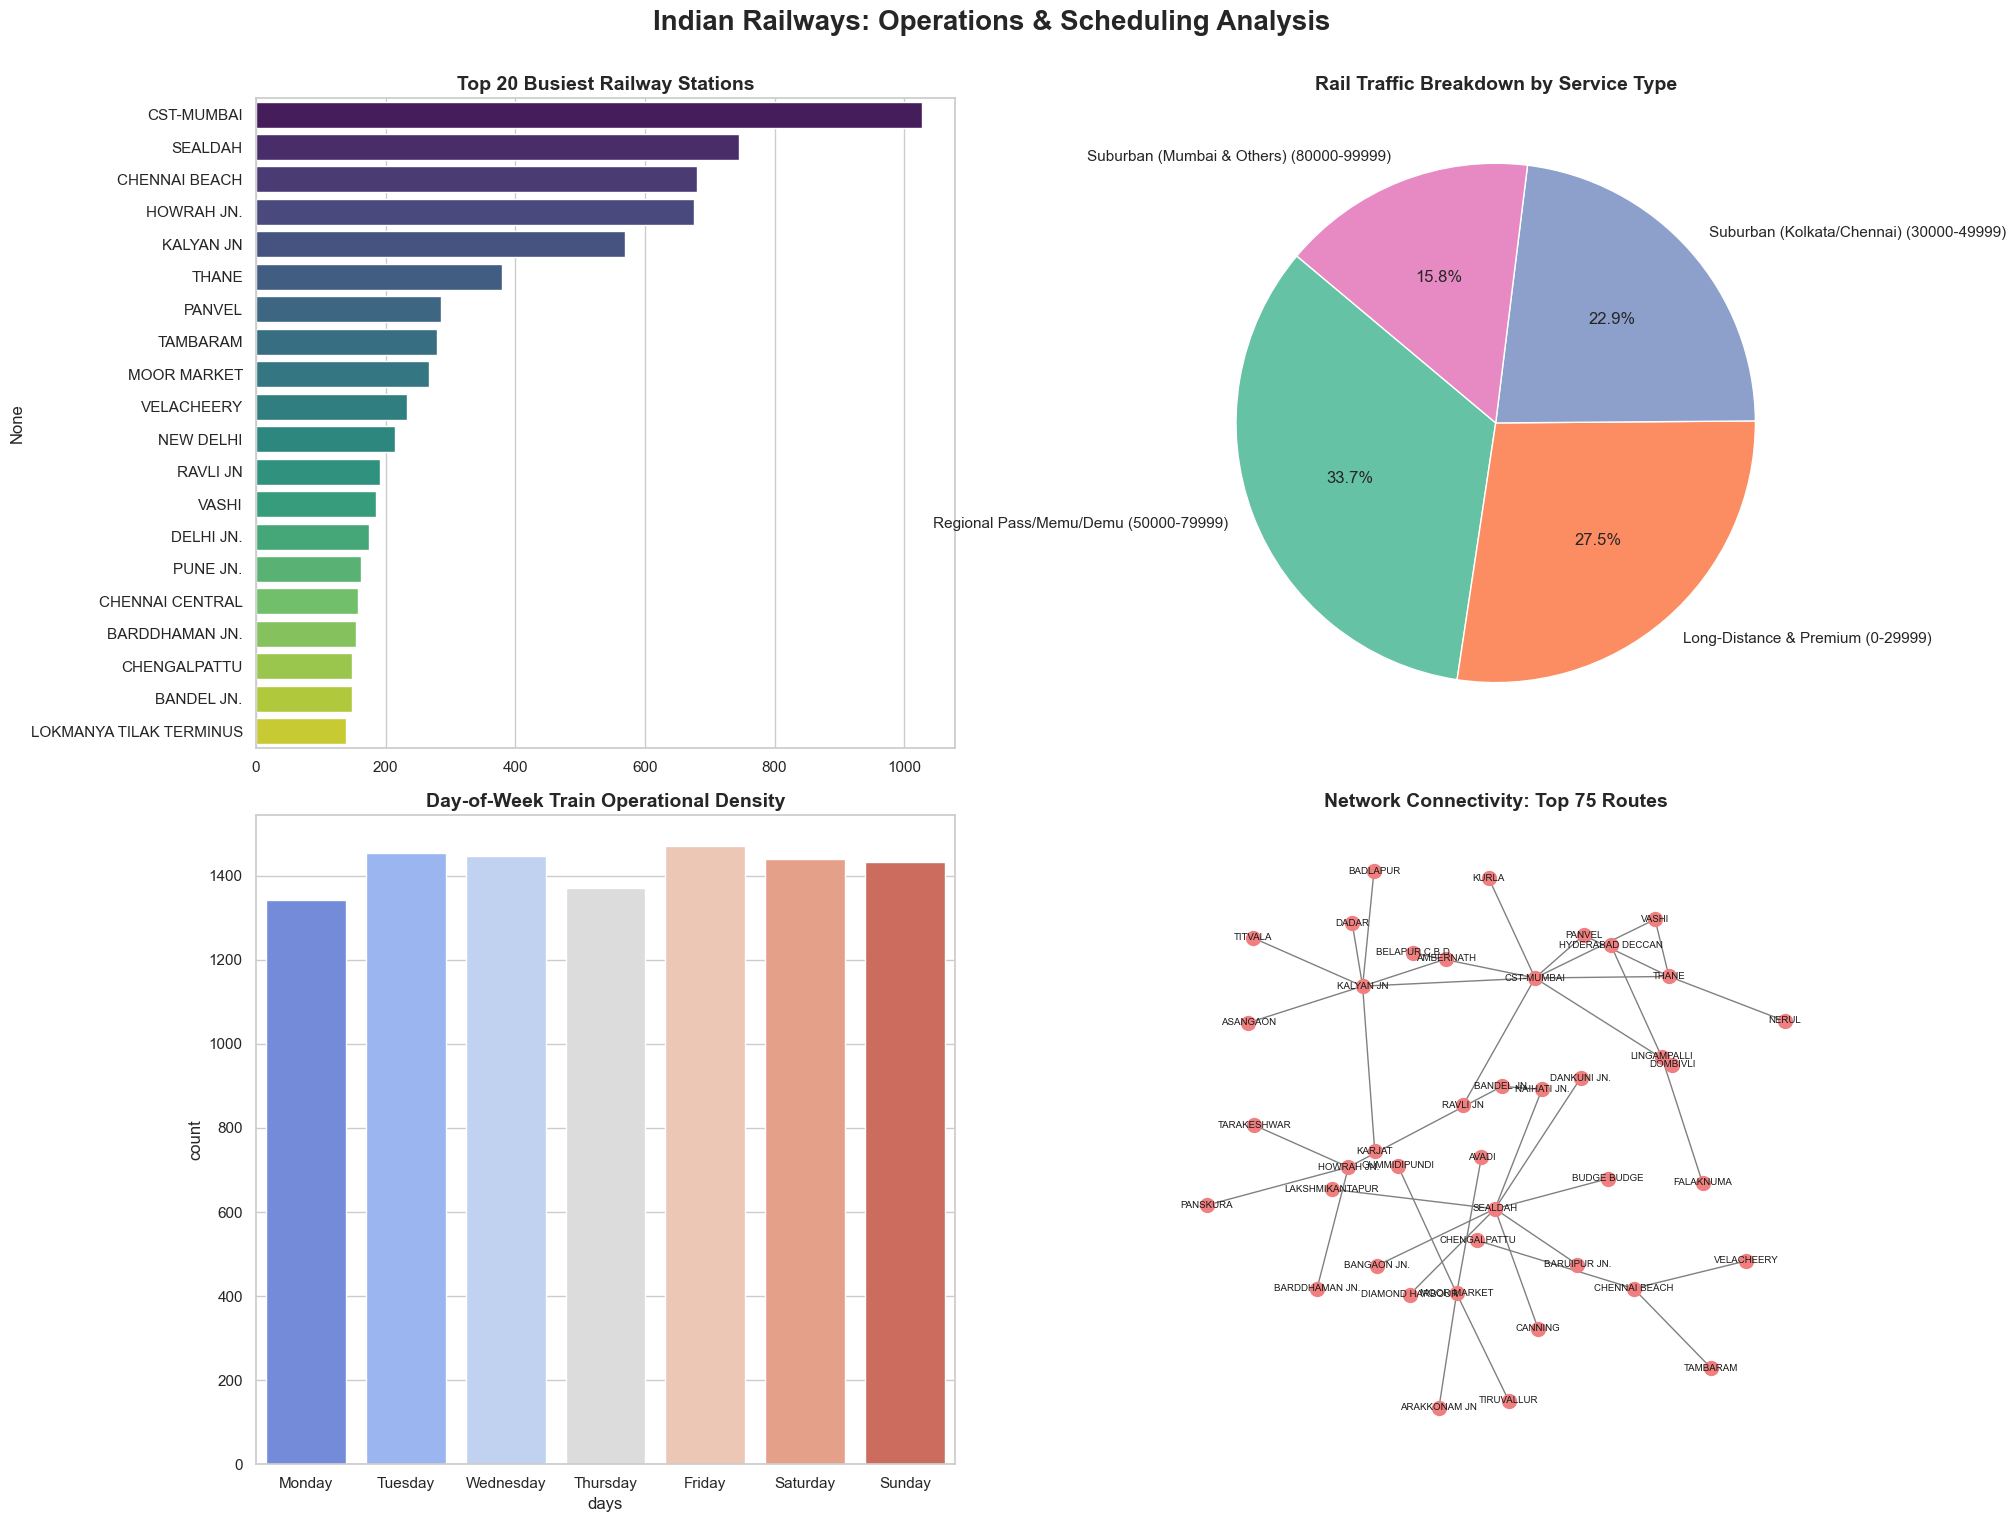

In [39]:
#Compile a comprehensive report that includes all the findings, visualizations, and insights gained from the data.
#Present the report in a clear and concise manner, suitable for stakeholders.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import networkx as nx 
import re 

# --- Feature Engineering ---
print("Categorizing train Types...")

def categorize_train(train_no):
    try:
        # Extract Numeric part
        num_part = re.sub(r"\D", "", str(train_no))
        
        # If no numbers found (Alphanumeric)
        if not num_part:
            return "Suburban (Alphanumeric/Specials)"

        # FIX 1 & 2: Correct indentation and variable name (num_part)
        t_no = int(num_part) 
        if t_no < 30000:
            return "Long-Distance & Premium (0-29999)"
        elif 30000 <= t_no < 50000:
            return "Suburban (Kolkata/Chennai) (30000-49999)"
        elif 50000 <= t_no < 80000:
            return "Regional Pass/Memu/Demu (50000-79999)"
        else:
            return "Suburban (Mumbai & Others) (80000-99999)"
    except Exception:
        return "Unknown/Special"

# Apply the fixed function
df["Train_Category"] = df["Train_No"].apply(categorize_train)

# --- Data Analysis & Insights ---
all_stations = pd.concat([df['Source_Station_Name'], df['Destination_Station_Name']])
top_20_stations = all_stations.value_counts().head(20)
category_counts = df['Train_Category'].value_counts()
day_counts = df['days'].value_counts().sort_index()

# --- Visualizations Dashboard ---
print("\nGenerating Visualizations...")
sns.set_theme(style="whitegrid")

# Create a figure
fig = plt.figure(figsize=(20, 16))

# Plot 1: Top 20 Busiest Stations
ax1 = fig.add_subplot(2, 2, 1)
sns.barplot(x=top_20_stations.values, y=top_20_stations.index, hue=top_20_stations.index, legend=False, palette="viridis", ax=ax1)
ax1.set_title('Top 20 Busiest Railway Stations', fontsize=14, fontweight='bold')

# Plot 2: Service Type Breakdown (Pie Chart)
ax2 = fig.add_subplot(2, 2, 2)
# Added a safety check to ensure category_counts is not empty
if not category_counts.empty:
    ax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
            startangle=140, colors=sns.color_palette("Set2"), wedgeprops={'edgecolor': 'white'})
    ax2.set_title('Rail Traffic Breakdown by Service Type', fontsize=14, fontweight='bold')
else:
    ax2.set_title('No Category Data Available', fontsize=14)

# Plot 3: Day-of-Week Operational Density
ax3 = fig.add_subplot(2, 2, 3)
sns.countplot(data=df, x='days', hue="days", legend=False, palette="coolwarm", ax=ax3)
ax3.set_title('Day-of-Week Train Operational Density', fontsize=14, fontweight='bold')

# Plot 4: Network Graph
ax4 = fig.add_subplot(2, 2, 4)
route_counts = df.groupby(['Source_Station_Name', 'Destination_Station_Name']).size().reset_index(name='Frequency')
top_routes = route_counts.sort_values(by='Frequency', ascending=False).head(75)
G = nx.from_pandas_edgelist(top_routes, 'Source_Station_Name', 'Destination_Station_Name', ['Frequency'])
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx(G, pos, ax=ax4, node_color='lightcoral', edge_color='gray', node_size=100, font_size=7, with_labels=True)
ax4.set_title('Network Connectivity: Top 75 Routes', fontsize=14, fontweight='bold')
ax4.axis('off')

# Final Layout Adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust to make room for suptitle
plt.suptitle('Indian Railways: Operations & Scheduling Analysis', fontsize=20, fontweight='bold')
plt.show()